In [1]:
from transformers import pipeline
import torch
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np

from qwen_vl_utils import process_vision_info

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Qwen3VLForConditionalGeneration
)
import re
from PIL import Image
import json 
import os

/jet/home/rohatgi/lab/rescue_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from huggingface_hub import snapshot_download

model_id = "AdaptLLM/remote-sensing-Qwen2.5-VL-3B-Instruct"
local_dir = "./remote-sensing-Qwen2.5-VL-3B-Instruct"

snapshot_download(repo_id=model_id, local_dir=local_dir)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_dir, torch_dtype="auto", device_map='cuda:0'
)

model = model.cuda()

Loading weights: 100%|██████████| 825/825 [01:21<00:00, 10.10it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [3]:
next(model.parameters()).device

device(type='cuda', index=0)

In [4]:
processor = AutoProcessor.from_pretrained(local_dir)

(1169, 1215, 3)


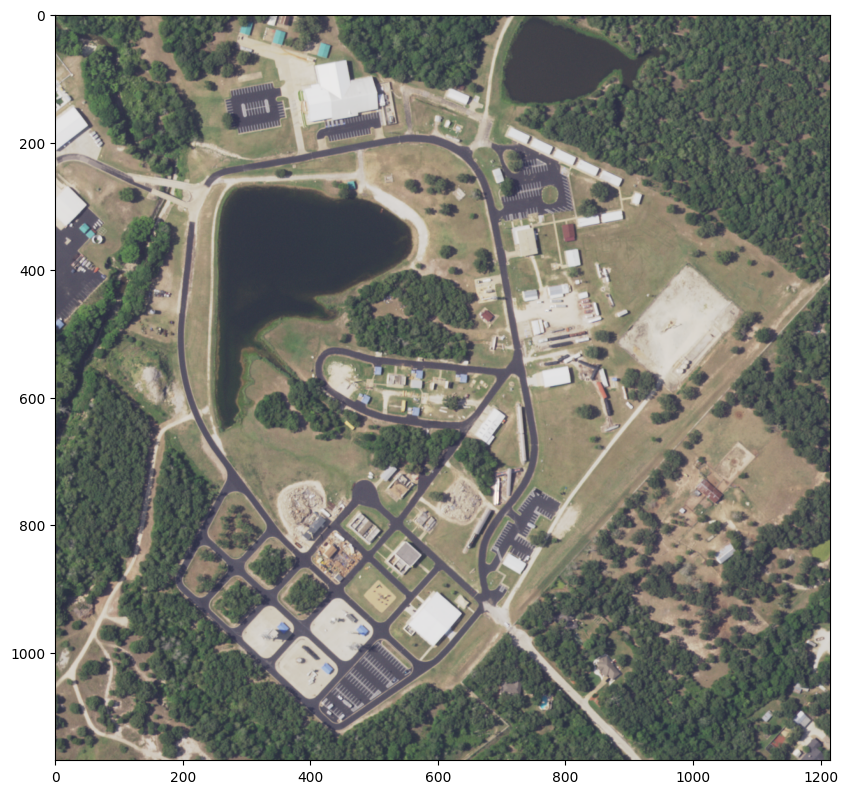

In [5]:
sample_img = xr.open_dataset('../data/disaster_city.nc')

rgb = sample_img.to_array()[1].values[:3, :, :]
rgb = np.moveaxis(rgb, 0, -1).astype('uint8')
print (rgb.shape)

plt.figure(figsize = (10, 10))
plt.imshow(rgb)

In [7]:
# {'polygon': [[x1, y1], [x2, y2], ...], 'label': 'object_name'}

In [8]:
image = Image.fromarray(rgb)

prompt_det = '''
You are an expert geospatial AI analyzing a top-down satellite image. I need to map non-traversable vegetation for a legged robot using a text-prompted segmentation model.

Carefully scan the entire image, paying special attention to the extreme edges and corners (especially the bottom-left). Notice how the lighting, shadows, and density change the appearance of the trees and plants.

Generate a comprehensive, comma-separated list of short, literal visual descriptions (noun phrases) that capture every variation of vegetation in this image. Include descriptions that account for dense shadows, thick canopies, and sparse brush.

Explain your process 

Example output style: light green sparse brush, dark shadowed dense forest, bright green individual tree crowns, deep green continuous canopy
'''


messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {"type": "text", "text": prompt_det},
        ],
    }
]
# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=1024)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print(output_text[0])

The process involves systematically identifying different types of vegetation based on their characteristics such as color, density, and shape. The light green sparse brush is indicative of areas where the vegetation is not densely packed, possibly due to sunlight filtering through or the presence of open spaces. The dark shadowed dense forest suggests a more mature forest with a high canopy density, which may be shaded by the overhang of the trees. The bright green individual tree crowns are likely to be younger trees or those with a more open canopy structure. The deep green continuous canopy represents a healthy, mature forest with a uniform canopy density. This methodical approach allows for the accurate mapping of non-traversable vegetation for a legged robot, ensuring that the terrain is accurately represented for navigation purposes. Therefore, the answer is light green sparse brush, dark shadowed dense forest, bright green individual tree crowns, deep green continuous canopy


In [7]:
# import json
# import ast
# import re
# import cv2 
# import numpy as np

# # Use re.finditer to find all matching list strings
# matches = re.finditer(r"(\[.*?\])", output_text[0])
# matches = list(matches)

# height, width = rgb.shape[:2]



# colors = [tuple(map(int, np.random.randint(0, 256, 3))) for _ in range(len(matches))]

# for i, match in enumerate(matches):
#     to_draw = rgb.copy()
#     to_draw = cv2.resize(to_draw, (1000, 1000))

#     bboxes = ast.literal_eval(match.group(1))
#     bboxes = list(map(int, bboxes))


#     pt1 = np.array((bboxes[1], bboxes[0]))
#     pt2 = np.array((bboxes[3], bboxes[2]))

#     to_draw = cv2.rectangle(to_draw, pt1, pt2, colors[i], 4)

#     # break 
# #         # Scale coordinates relative to image dimensions
# #         scaled_pts = [(int(x * width / 1000), int(y * height / 1000)) for x, y in polygon]

# #         pts = np.array(scaled_pts, dtype=np.int32)
# #         to_draw = cv2.fillPoly(to_draw, [pts], (255, 0, 0))

#     plt.figure(figsize = (10, 10))
#     plt.imshow(to_draw)

